## Klasyfikacja - podstawy

Na podstawie wybranego interesującego zbioru danych zademonstruj granice decyzyjne czterech algorytmów klasyfikacyjnych: Naive Bayes (MB / Bern), Logistic Regression, Linear SVM oraz Kernel SVM. Wizualizację przeprowadź w przestrzeni dwuwymiarowej, stosując oba podejścia do redukcji wymiarowości:
- Dwa najlepsze predyktory — wybrane na podstawie analizy istotności cech
- PCA — dwie pierwsze składowe główne wyjaśniające największą część wariancji

Dla każdego algorytmu i każdego podejścia narysuj siatkę decyzyjną (decision boundary) nałożoną na punkty danych. Porównaj kształt granic decyzyjnych między algorytmami


In [106]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

In [142]:
df_red = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",sep=";")
df_white = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv",sep=";")
df = pd.concat([df_red, df_white], ignore_index=True)
X = df.drop(["quality"], axis=1)
y = df["quality"].apply(lambda x: 1 if x >= 6 else 0)
feature_names = X.columns

In [109]:
from sklearn.preprocessing import StandardScaler
# We normalize the data beforehand so that all plots are exactly the same.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)
print(len(X), len(y))

6497 6497


In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [111]:
from sklearn.decomposition import PCA

def perform_pca():
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # loadings = pca.components_   # shape (2, n_features)
    # print("PCA components (weights for each original feature):")
    # print(loadings)

    pc1_top = feature_names[np.argmax(np.abs(pca.components_[0]))]
    pc2_top = feature_names[np.argmax(np.abs(pca.components_[1]))]

    print("Most important feature in PC1:", pc1_top)
    print("Most important feature in PC2:", pc2_top)

    importance = np.abs(pca.components_[0]) + np.abs(pca.components_[1])
    importance /= importance.sum()
    # for imp, feat in zip(importance, feature_names):
        # print(f"Feature {feat} has importance {imp:.2f}")

    top2 = np.argsort(-importance)[:2]
    print("Top 2 features overall:", feature_names[top2])
    return X_train_pca, X_test_pca

X_train_pca, X_test_pca = perform_pca()

Most important feature in PC1: total sulfur dioxide
Most important feature in PC2: density
Top 2 features overall: Index(['residual sugar', 'density'], dtype='object')


In [112]:
"""
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

feature_names = X.columns
num_features = len(X.columns)

fig, ax = subplots(num_features, num_features, figsize=(20, 20))

for i in range(num_features):
    for j in range(num_features):
        if i == j:
            ax[i, j].hist(X.iloc[:, i])
        else:
            ax[i, j].scatter(X.iloc[:, i], X.iloc[:, j], c=y)

        if j == 0:
            ax[i, j].set_ylabel(X.columns[i])
        if i == num_features - 1:
            ax[i, j].set_xlabel(X.columns[j])

fig.tight_layout()
plt.show()
"""

'\nimport matplotlib.pyplot as plt\nfrom matplotlib.pyplot import subplots\n\nfeature_names = X.columns\nnum_features = len(X.columns)\n\nfig, ax = subplots(num_features, num_features, figsize=(20, 20))\n\nfor i in range(num_features):\n    for j in range(num_features):\n        if i == j:\n            ax[i, j].hist(X.iloc[:, i])\n        else:\n            ax[i, j].scatter(X.iloc[:, i], X.iloc[:, j], c=y)\n\n        if j == 0:\n            ax[i, j].set_ylabel(X.columns[i])\n        if i == num_features - 1:\n            ax[i, j].set_xlabel(X.columns[j])\n\nfig.tight_layout()\nplt.show()\n'

In [136]:
def plot_two_boundaries(
    model_full,
    model_name,
    top1_pred,
    top2_pred,
    X_train,
    X_test,
    y_test,
    model_pca,
    X_train_pca,
    X_test_pca,
    y_test_pca,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    # ---------- Unified score extractor ----------
    def boundary_score(model, X):
        """Return a 1D score and a threshold for binary boundary drawing."""

        if hasattr(model, "decision_function"):
            raw = model.decision_function(X)

            # --- KEY FIX FOR SVM: decision_function sometimes returns shape (n,2) ---
            if raw.ndim == 2 and raw.shape[1] == 2:
                raw = raw[:, 1] - raw[:, 0]

            return np.asarray(raw), 0.0

        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X)
            if proba.ndim == 2:
                return proba[:, 1], 0.5
            return proba, 0.5

        return None, None

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ======================================================================
    # LEFT PLOT — ORIGINAL FEATURES (top 2 predictors)
    # ======================================================================
    ax = axes[0]
    ax.set_title(f"{model_name} — top 2 predictors")

    x_min, x_max = X_test[top1_pred].min() - 0.5, X_test[top1_pred].max() + 0.5
    y_min, y_max = X_test[top2_pred].min() - 0.5, X_test[top2_pred].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    base = X_train.mean(numeric_only=True)
    grid = np.tile(base.values, (xx.size, 1))
    grid_df = pd.DataFrame(grid, columns=X_train.columns)
    grid_df[top1_pred] = xx.ravel()
    grid_df[top2_pred] = yy.ravel()

    # predictions
    Z = model_full.predict(grid_df).reshape(xx.shape)
    score, level = boundary_score(model_full, grid_df)
    if score is not None:
        score = score.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=plt.cm.RdYlBu, alpha=0.8)

    if score is not None:
        ax.contour(xx, yy, score, levels=[level], colors="k", linewidths=2)

    ax.scatter(
        X_test[top1_pred],
        X_test[top2_pred],
        c=y_test,
        cmap=plt.cm.RdYlBu,
        edgecolor="k",
        s=25,
    )
    ax.set_xlabel(top1_pred)
    ax.set_ylabel(top2_pred)

    # ======================================================================
    # RIGHT PLOT — PCA 2 COMPONENTS
    # ======================================================================
    ax = axes[1]
    ax.set_title(f"{model_name} — PCA (2 components)")

    # Grid covering both train & test
    pca_all = np.vstack([X_train_pca, X_test_pca])
    x_min, x_max = pca_all[:, 0].min() - 0.5, pca_all[:, 0].max() + 0.5
    y_min, y_max = pca_all[:, 1].min() - 0.5, pca_all[:, 1].max() + 0.5

    gx, gy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    grid_pca = np.c_[gx.ravel(), gy.ravel()]

    Z2 = model_pca.predict(grid_pca).reshape(gx.shape)
    score2, level2 = boundary_score(model_pca, grid_pca)
    if score2 is not None:
        score2 = score2.reshape(gx.shape)

    ax.contourf(gx, gy, Z2, levels=[-0.5, 0.5, 1.5], cmap=plt.cm.RdYlBu, alpha=0.8)

    if score2 is not None:
        ax.contour(gx, gy, score2, levels=[level2], colors="k", linewidths=2)

    ax.scatter(
        X_test_pca[:, 0],
        X_test_pca[:, 1],
        c=y_test_pca,
        cmap=plt.cm.RdYlBu,
        edgecolor="k",
        s=25,
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    plt.tight_layout()
    plt.show()

In [137]:
def try_model(create_model_fn, model_name, top2_predictors_fn, response_method="predict"):
    model_full = create_model_fn(X_train, y_train)
    y_pred_without_pca = model_full.predict(X_test)
    print(f"accuracy without pca: {accuracy_score(y_test, y_pred_without_pca)}")
    top1_pred, top2_pred = top2_predictors_fn(model_full)
    print(f"top2 predictiors are: {top1_pred}, {top2_pred}")

    model_pca = create_model_fn(X_train_pca, y_train)
    y_pred_with_pca = model_pca.predict(X_test_pca)
    print(f"accuracy with pca: {accuracy_score(y_test, y_pred_with_pca)}")
    plot_two_boundaries(
      model_full=model_full,
      model_name=model_name,
      top1_pred=top1_pred,
      top2_pred=top2_pred,
      X_train=X_train,
      X_test=X_test,
      y_test=y_test,
      model_pca=model_pca,
      X_train_pca=X_train_pca,
      X_test_pca=X_test_pca,
      y_test_pca=y_test,
  )

In [115]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

def get_gaussian(X_train, y_train):
    gaussian_model = GaussianNB()
    gaussian_model.fit(X_train, y_train);
    return gaussian_model

In [116]:
def measure_gaussian_importance(gaussian_model):
    # Measure predictor importance.
    means = gaussian_model.theta_          # shape: (n_classes, n_features)
    variances = gaussian_model.var_        # shape: (n_classes, n_features)
    priors = gaussian_model.class_prior_   # shape: (n_classes,)

    eps = 1e-12

    # global mean liczony jako ważona średnia po klasach
    global_mean = np.sum(priors[:, None] * means, axis=0)
    # międzyklasowa separacja średnich
    between = np.sum(priors[:, None] * (means - global_mean) ** 2, axis=0)
    # średnia wariancja wewnątrz klas
    within = np.sum(priors[:, None] * variances, axis=0) + eps

    importance = between / within

    result = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importance,
        "between_class_separation": between,
        "within_class_variance": within
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return result["feature"].values[:2]

accuracy without pca: 0.6915384615384615
top2 predictiors are: alcohol, volatile acidity
accuracy with pca: 0.6484615384615384


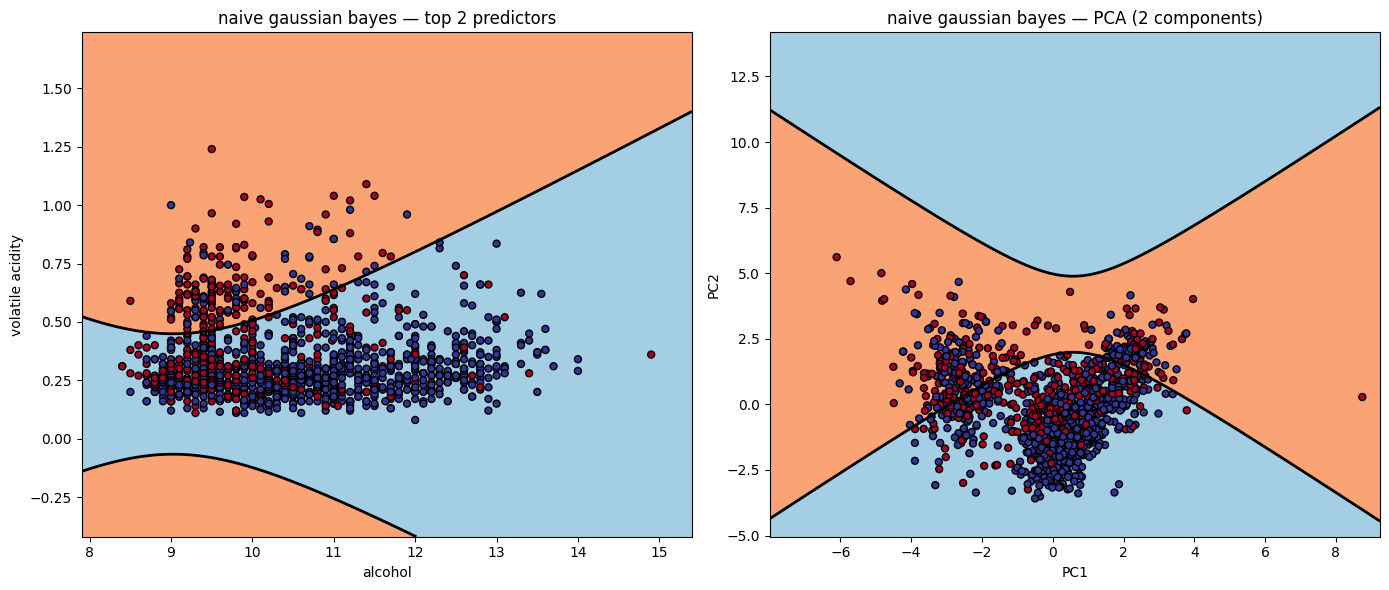

In [138]:
try_model(get_gaussian, "naive gaussian bayes", measure_gaussian_importance)

In [118]:
# Logistic regression
from sklearn.linear_model import LogisticRegression

def get_logistic_regression_model(X_train, y_train):
    logistic_model = make_pipeline(StandardScaler(), LogisticRegression())
    logistic_model.fit(X_train, y_train)
    return logistic_model

In [119]:
def get_top2_logistic(model):
    coef = model[-1].coef_[0]
    return feature_names[np.argsort(abs(coef))[-2:]]

accuracy without pca: 0.7238461538461538
top2 predictiors are: volatile acidity, alcohol
accuracy with pca: 0.6492307692307693


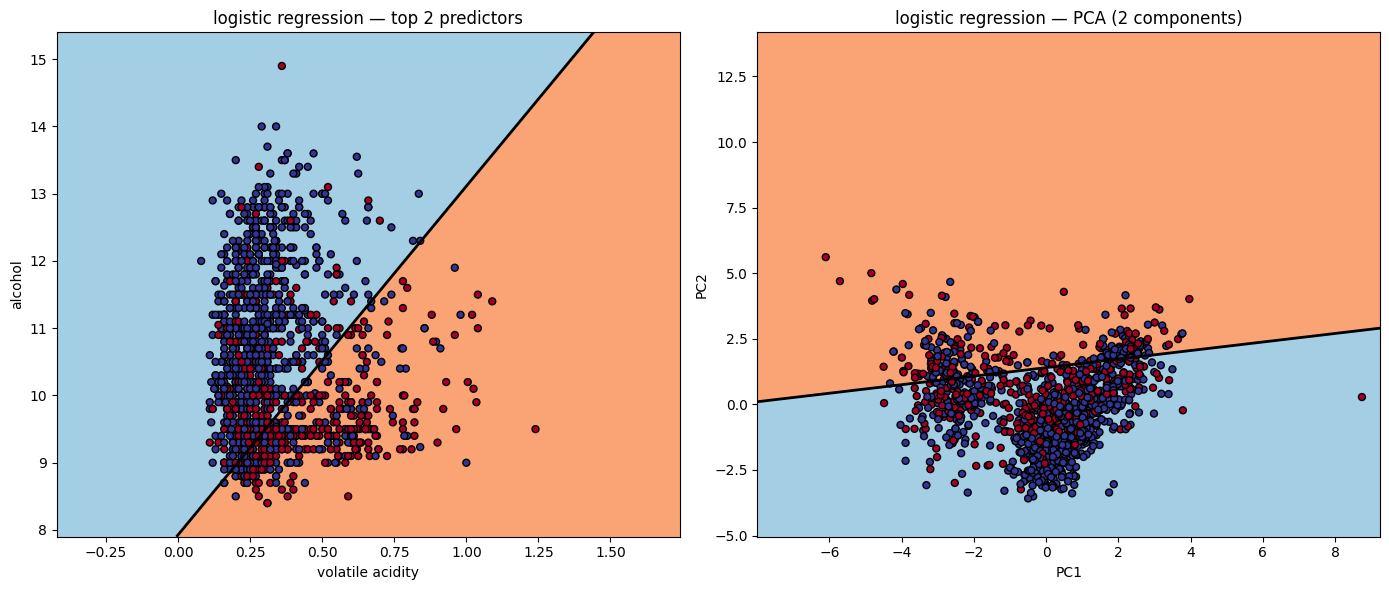

In [133]:
try_model(get_logistic_regression_model, "logistic regression", get_top2_logistic)

accuracy without pca: 0.7307692307692307
top2 predictiors are: volatile acidity, alcohol
accuracy with pca: 0.6530769230769231


KeyboardInterrupt: 

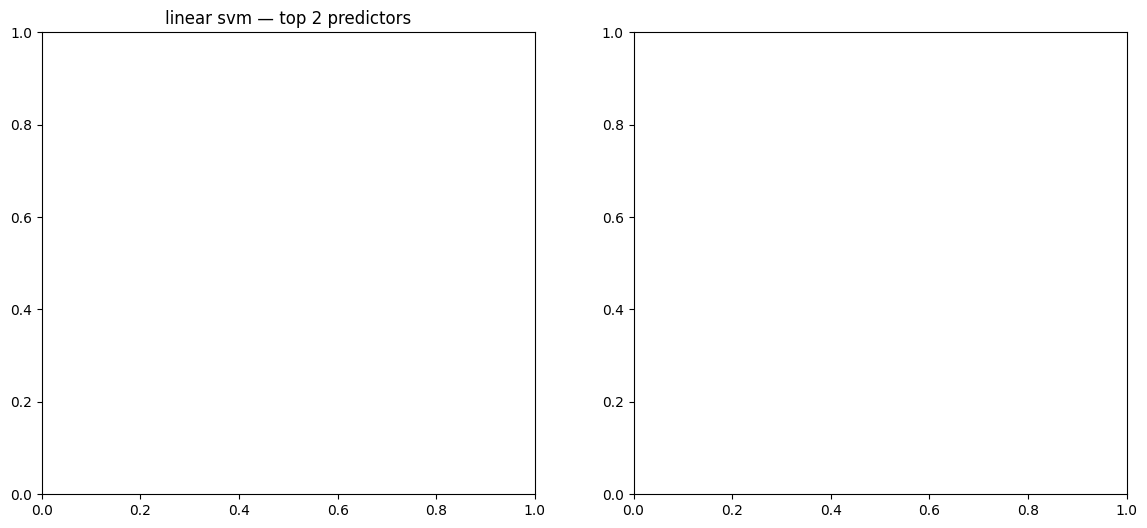

In [141]:
# Linear SVM
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

def get_linear_svm_model(X_train, y_train):
    svm_model = make_pipeline(StandardScaler(), SVC(kernel="linear"))
    svm_model.fit(X_train, y_train)
    return svm_model

try_model(get_linear_svm_model, "linear svm", get_top2_logistic)

accuracy without pca: 0.7307692307692307
top2 predictiors are: volatile acidity, alcohol
accuracy with pca: 0.6530769230769231


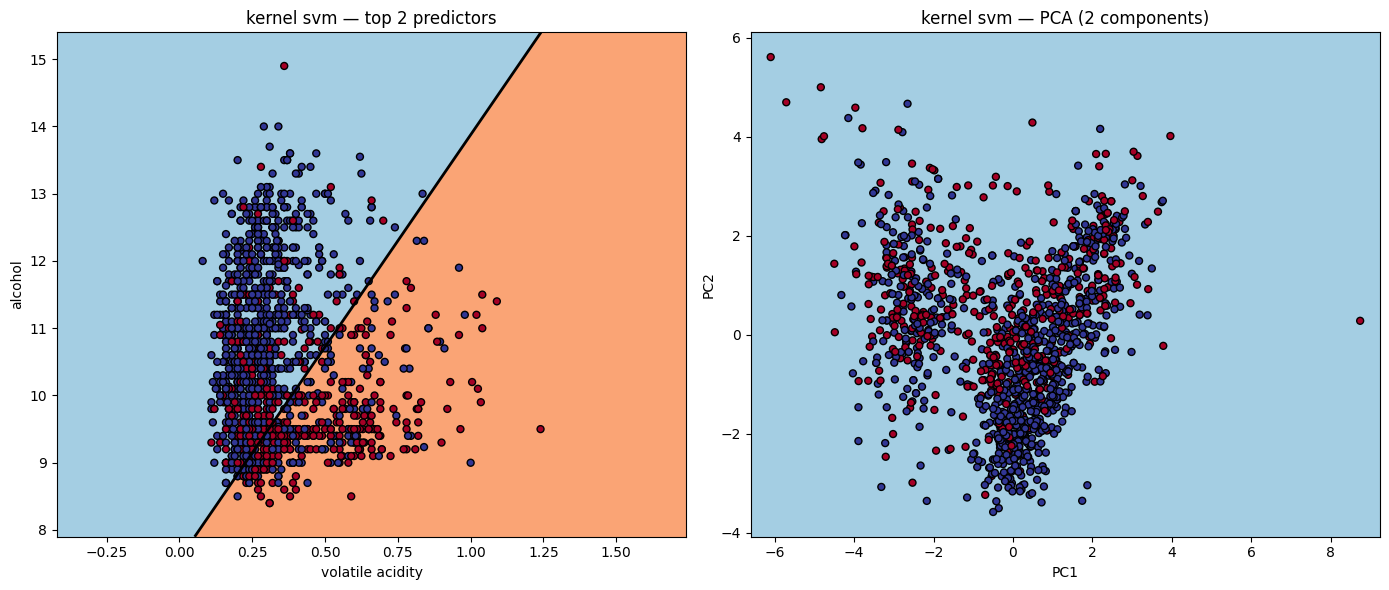

In [129]:
# Kernel SVM
def get_kernel_svm_model(X_train, y_train):
    svm_model = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
    svm_model.fit(X_train, y_train)
    return svm_model

try_model(get_linear_svm_model, "kernel svm", get_top2_logistic)

## Analiza skupień
Na podstawie interesującego zbioru danych zademonstruj, jak dobrać optymalną liczbę klastrów. Omów następujące podejścia:
- K-means — metoda łokcia (Elbow Method), współczynnik sylwetki (Silhouette Score)
- Gaussian Mixture Models — kryterium informacyjne Bayesa (BIC)


In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [155]:
df_red = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",sep=";")
df_white = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv",sep=";")
df = pd.concat([df_red, df_white], ignore_index=True)

X = df.drop(["quality"], axis=1)
y = df["quality"].apply(lambda x: 1 if x >= 6 else 0)
feature_names = X.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

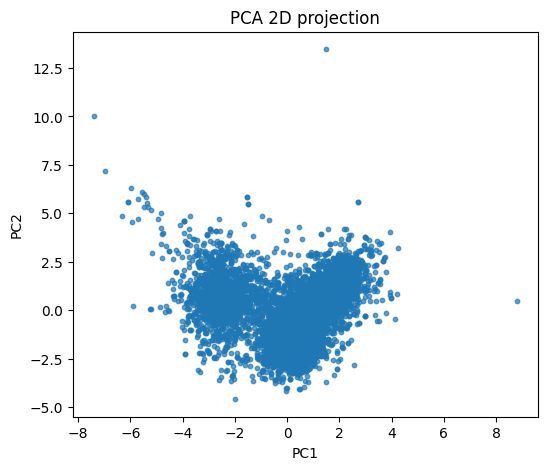

In [166]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.7)
plt.title("PCA 2D projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

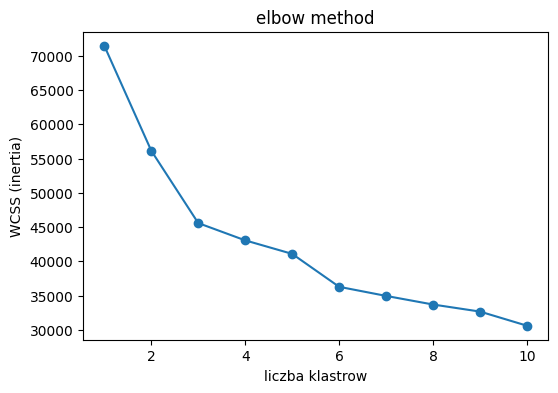

In [167]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("liczba klastrow")
plt.ylabel("WCSS (inertia)")
plt.title("elbow method")
plt.show()

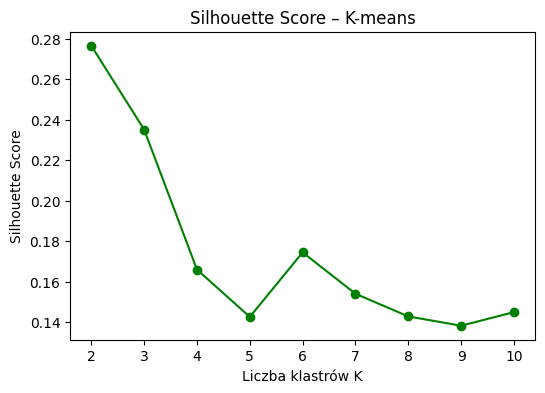

In [158]:
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2, 11), sil_scores, marker='o', color='green')
plt.xlabel("Liczba klastrów K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score – K-means")
plt.show()

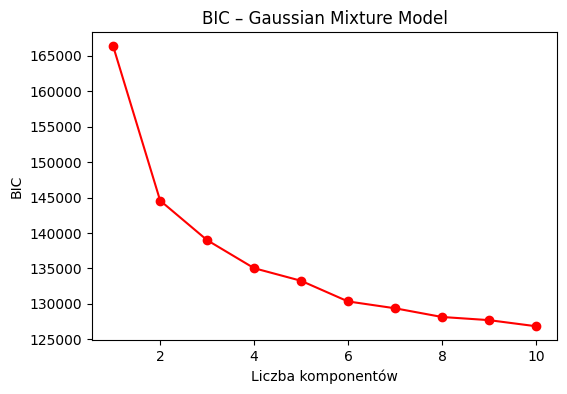

In [159]:
bics = []
for k in range(1, 11):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), bics, marker='o', color='red')
plt.xlabel("Liczba komponentów")
plt.ylabel("BIC")
plt.title("BIC – Gaussian Mixture Model")
plt.show()

In [163]:
best_k = 3

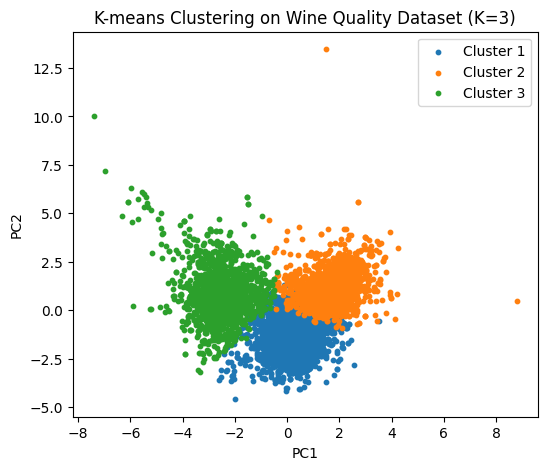

In [164]:
km_final = KMeans(n_clusters=best_k, random_state=42)
labels_final = km_final.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
for i in range(best_k):
    plt.scatter(X_pca[labels_final==i,0], X_pca[labels_final==i,1], label=f"Cluster {i+1}", s=10)
plt.title(f"K-means Clustering on Wine Quality Dataset (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

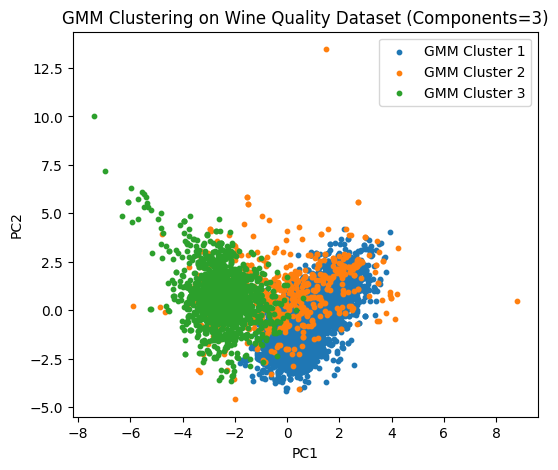

In [165]:
gmm_final = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
labels_gmm = gmm_final.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
for i in range(best_k):
    plt.scatter(X_pca[labels_gmm==i,0], X_pca[labels_gmm==i,1], label=f"GMM Cluster {i+1}", s=10)
plt.title(f"GMM Clustering on Wine Quality Dataset (Components={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## Uczenie maszynowe
Na podstawie interesującego zbioru danych zademonstruj skuteczność wybranego algorytmu klasyfikacji binarnej przy pomocy krzywej ROC wyznaczonej metodą walidacji krzyżowej i przedstawionej w formie interaktywnej wizualizacji (np. przy użyciu Plotly). Wskaż optymalny próg klasyfikacji przy kryterium indeksu Youdena (Youden's J statistic).
